# Method 34 - Polar stereographic projection, 99th percentile 1980-2000 and 93.5th percentile 2000-2023 random sampling overflow bins and month distribution average cap

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.mixture import GaussianMixture
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from funcs import profileNo_vs_xy_bins, sample_cap_bins_xy, plot_geo, cross_sec_lon, cross_sec_lon_prob

In [2]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]

In [3]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)
torch.manual_seed(seed)

In [4]:
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']

In [5]:
# Scale data
scaler = StandardScaler()
scaled_ST = scaler.fit_transform(df_ST[features])

In [6]:
# Extract values into a tensor
X = torch.tensor(scaled_ST, dtype=torch.float32)
dataset = TensorDataset(X)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [7]:
# Define Variational Autoencoder

class VAE(nn.Module):
    def __init__(self, input_dim=3, latent_dim=2):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, 16)
        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 16)
        self.fc3 = nn.Linear(16, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return self.fc3(h)     # no sigmoid for real-valued data

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [8]:
# Define loss function (mse and KL divergence)
def vae_loss(recon_x, x, mu, logvar):
    mse = F.mse_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return mse + kld

In [12]:
import copy

device = "cuda" if torch.cuda.is_available() else "cpu"
model = VAE(input_dim=df_ST[features].shape[1], latent_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 50
patience = 5
best_loss = float("inf")
patience_counter = 0
best_model_state = None

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for batch in loader:
        x = batch[0].to(device)
        optimizer.zero_grad()

        recon, mu, logvar = model(x)
        loss = vae_loss(recon, x, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")

    # ---- Early stopping logic ----
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

Epoch 1 | Loss: 1.2158
Epoch 2 | Loss: 1.2094
Epoch 3 | Loss: 1.2094
Epoch 4 | Loss: 1.2089
Epoch 5 | Loss: 1.2084
Epoch 6 | Loss: 1.2084
Epoch 7 | Loss: 1.2086
Epoch 8 | Loss: 1.2083
Epoch 9 | Loss: 1.2086
Epoch 10 | Loss: 1.2084
Epoch 11 | Loss: 1.2081
Epoch 12 | Loss: 1.2083
Epoch 13 | Loss: 1.2083
Epoch 14 | Loss: 1.2084
Epoch 15 | Loss: 1.2082
Epoch 16 | Loss: 1.2081
Early stopping triggered at epoch 16


In [13]:
model.eval()
with torch.no_grad():
    mu, logvar = model.encode(X.to(device))
    z = mu.cpu()   # latent representation

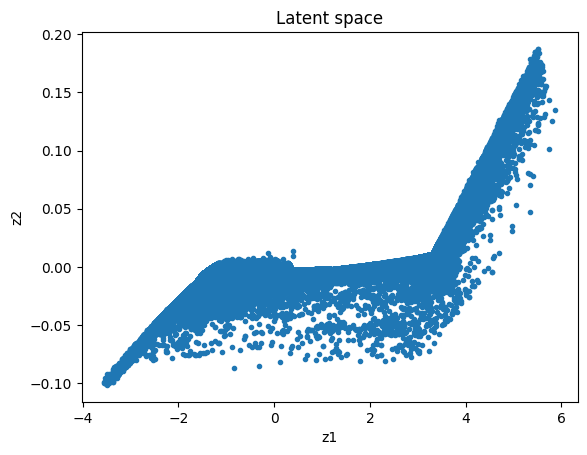

In [14]:
plt.scatter(z[:,0].cpu().tolist(), z[:,1].cpu().tolist(), marker='.')
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Latent space")
plt.show()

In [15]:
# Four clusters for comparison
n_clusters = 4

In [16]:
gmm = GaussianMixture(n_components=n_clusters, random_state=seed)
gmm.fit(z)
gmm_labels = gmm.predict(z)
df_ST['gmm_label_4'] = gmm_labels.astype(int)

/Users/franciscagomes/PhD/WM_class/.venv/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


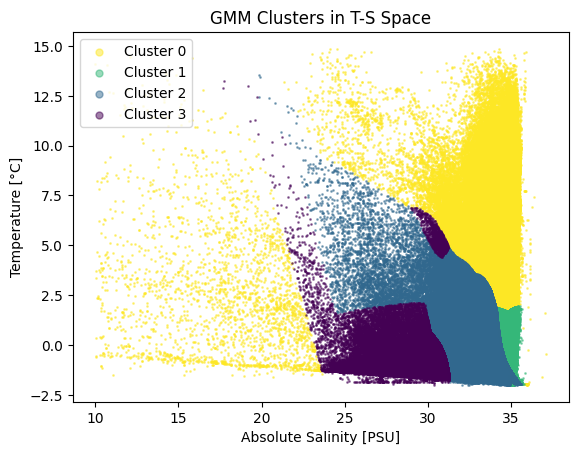

In [17]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_ST['gmm_label_4'] == i
    plt.scatter(
        df_ST.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_ST.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [18]:
# Sample geographically for better plotting
df_sampled_plot = df_ST.sample(n=70000, random_state=seed)
plot_geo(df_sampled_plot, n_clusters)

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Paper1/TS_again/funcs.py:625: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



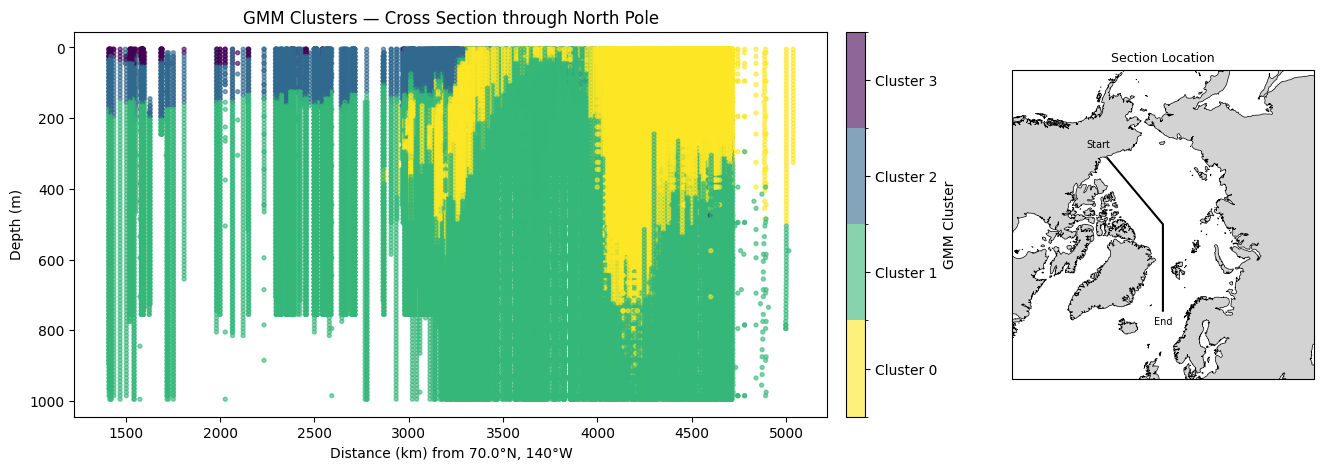

In [19]:
cross_sec_lon(df_ST, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [20]:
# Get probabilities for each cluster
for i in range(n_clusters):
    df_ST[f'prob_cluster_{i}'] = gmm.predict_proba(z)[:, i]

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Paper1/TS_again/funcs.py:717: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



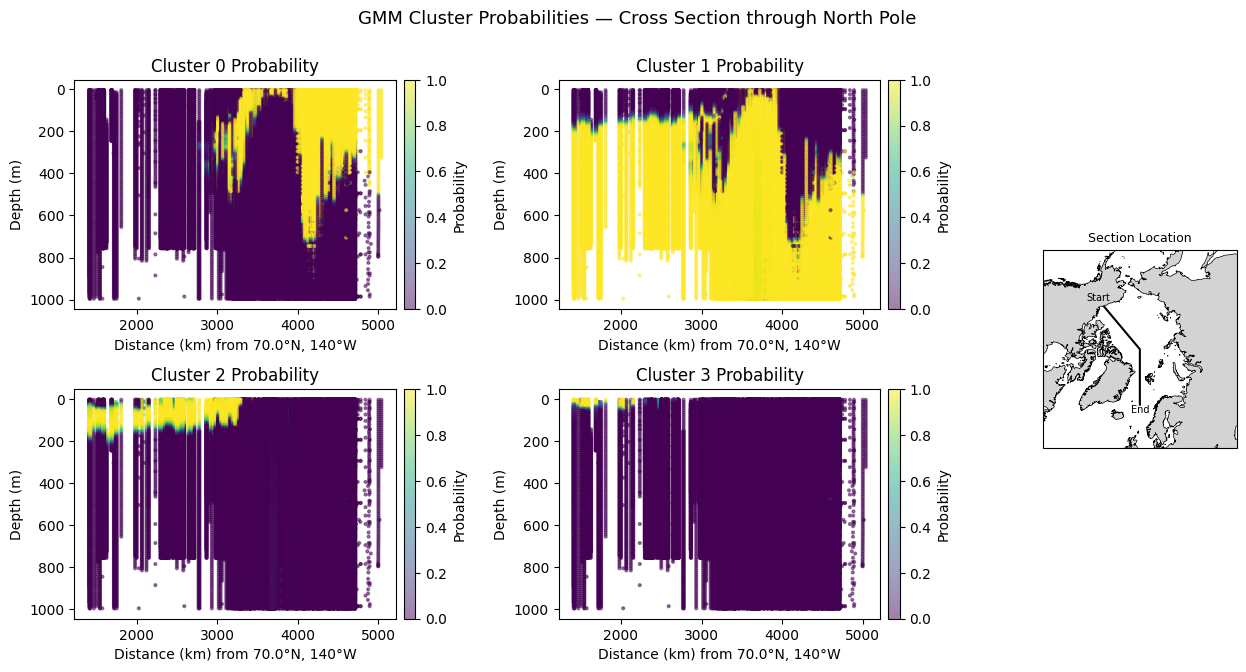

In [21]:
cross_sec_lon_prob(df_ST, -180, tol=0.5, start_lat=70.0, start_lon=-140)